In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "/content/county_month_combined.parquet"
)

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/county_month_combined.parquet'

In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
S2301_C04_017,17371,99.793187
S2301_C02_017,17371,99.793187
S2301_C01_017,17371,99.793187
S2301_C03_017,17371,99.793187
S2301_C02_015,17347,99.655311
...,...,...
county,0,0.000000
sales_liters,0,0.000000
sales_gallons,0,0.000000
year,0,0.000000


In [ ]:
employment = pd.read_parquet(
    "/content/employment_status_for_iowa_civilian_population_16_years_old_and_over_acs_1_year_estimate_1188_rows.parquet"
)

employment.shape

(34560, 27)

In [ ]:
emp_county = employment[
    employment["geography_type"] == "County"
].copy()

print("County employment rows:", len(emp_county))
print(
    "Unique counties:",
    emp_county["county_fips_code"].nunique()
)

print("\nCounties represented by year:")

print(
    emp_county
    .groupby("data_collection_period")
    ["county_fips_code"]
    .nunique()
)

County employment rows: 18600
Unique counties: 10

Counties represented by year:
data_collection_period
2010    10
2011    10
2012    10
2013    10
2014    10
2015    10
2016    10
2017    10
2018    10
2019    10
2021    10
2022    10
2023    10
2024    10
Name: county_fips_code, dtype: int64


In [ ]:
#Only 10 counties are represented in the employment dataset
employment_cols = [
    col for col in df.columns
    if col.startswith("S2301_")
]

print("Employment columns:", len(employment_cols))

Employment columns: 132


In [ ]:
df_main = df.drop(
    columns=employment_cols
).copy()

df_main.shape

(17407, 11)

We initially considered ACS 1-year employment estimates as predictors. Exploratory analysis showed that the dataset covered only 10 Iowa counties, which would exclude most counties from models requiring these variables. Because this missingness was systematically related to geographic coverage rather than random missing observations, we excluded these variables from our primary statewide models rather than dropping counties or imputing unsupported values.

In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17407 entries, 0 to 17406
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   county                   17407 non-null  object        
 1   year_month               17407 non-null  datetime64[ns]
 2   sales_dollars            17407 non-null  float64       
 3   sales_bottles            17407 non-null  int64         
 4   sales_liters             17407 non-null  float64       
 5   sales_gallons            17407 non-null  float64       
 6   avg_alcohol_level_g210L  17399 non-null  float64       
 7   num_tests                17399 non-null  float64       
 8   county_population        15427 non-null  float64       
 9   year                     17407 non-null  int32         
 10  month                    17407 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1), object(1)
memory usage: 1.3+ MB


In [ ]:
df_main.columns.tolist()

['county',
 'year_month',
 'sales_dollars',
 'sales_bottles',
 'sales_liters',
 'sales_gallons',
 'avg_alcohol_level_g210L',
 'num_tests',
 'county_population',
 'year',
 'month']

In [ ]:
#Separate year and month
df_main["year_month"] = pd.to_datetime(
    df_main["year_month"]
)

df_main["year"] = df_main["year_month"].dt.year
df_main["month"] = df_main["year_month"].dt.month

In [ ]:
#all counties represented
df_main.groupby("year").agg(
    rows=("county", "size"),
    counties=("county", "nunique")
)

,rows,counties
year,,
2012,1187,99
2013,1186,99
2014,1183,99
2015,1186,99
2016,1187,99
2017,1188,99
2018,1188,99
2019,1184,99
2020,1186,99


In [ ]:
#Check for duplicates
duplicates = (
    df_main.groupby(["county", "year_month"])
      .size()
      .reset_index(name="count")
)

duplicates[
    duplicates["count"] > 1
]

,county,year_month,count


In [ ]:
#Population not represented in 2025-2026
population_coverage = (
    df_main.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "county_population",
              lambda x: x.notna().sum()
          )
      )
)

population_coverage

,counties,counties_with_population
year,,
2012,99,1187
2013,99,1186
2014,99,1183
2015,99,1186
2016,99,1187
2017,99,1188
2018,99,1188
2019,99,1184
2020,99,1186


In [ ]:
#BAC represented in all rows
bac_coverage = (
    df.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "avg_alcohol_level_g210L",
              lambda x: x.notna().sum()
          )
      )
)

bac_coverage

,counties,counties_with_population
year,,
2012,99,1187
2013,99,1186
2014,99,1183
2015,99,1186
2016,99,1187
2017,99,1188
2018,99,1188
2019,99,1184
2020,99,1186


In [ ]:
booze = df_main[
    [
        "county",
        "year_month",
        "year",
        "month",
        "sales_dollars",
        "sales_bottles",
        "sales_liters",
        "sales_gallons",
        "county_population"
    ]
].copy()

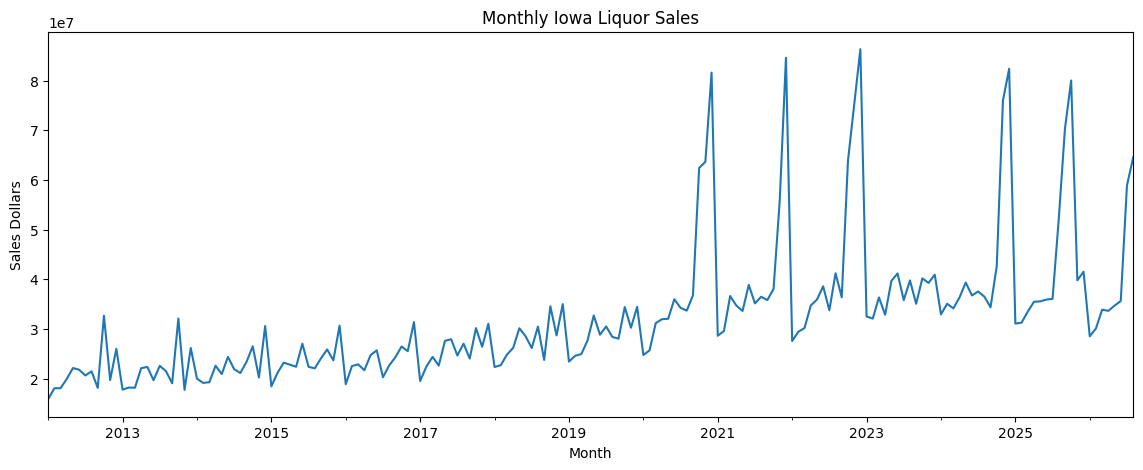

In [ ]:
state_monthly = (
    booze.groupby("year_month")["sales_dollars"]
         .sum()
)

state_monthly.plot(
    figsize=(14, 5),
    title="Monthly Iowa Liquor Sales"
)

plt.ylabel("Sales Dollars")
plt.xlabel("Month")
plt.show()

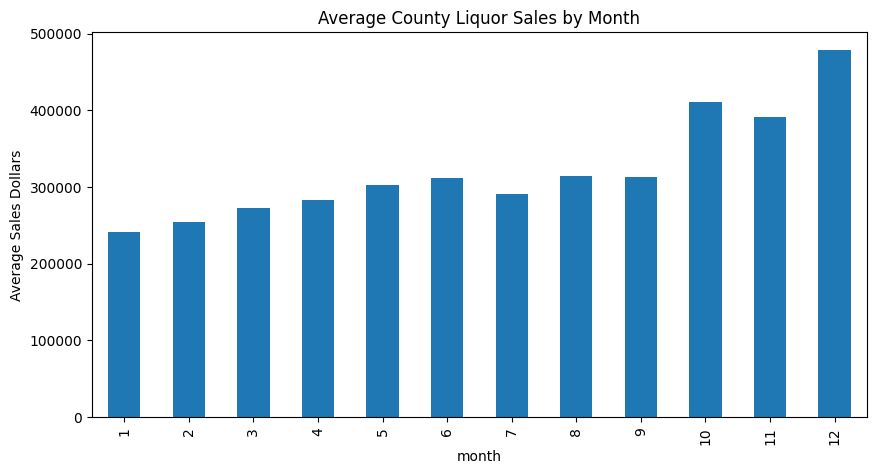

In [ ]:
monthly_pattern = (
    booze[
        booze["year"] < 2026
    ]
    .groupby("month")["sales_dollars"]
    .mean()
)

monthly_pattern.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average County Liquor Sales by Month"
)

plt.ylabel("Average Sales Dollars")
plt.show()

In [ ]:
#Average monthly sales by county
county_avg = (
    booze.groupby("county")["sales_dollars"]
         .mean()
         .sort_values(ascending=False)
)

county_avg.head(15)

,sales_dollars
county,
POLK,7.389746e+06
LINN,2.782284e+06
SCOTT,2.212532e+06
JOHNSON,1.887965e+06
BLACK HAWK,1.729035e+06
POTTAWATTAMIE,1.170590e+06
WOODBURY,1.110240e+06
STORY,9.459282e+05
DUBUQUE,9.421202e+05


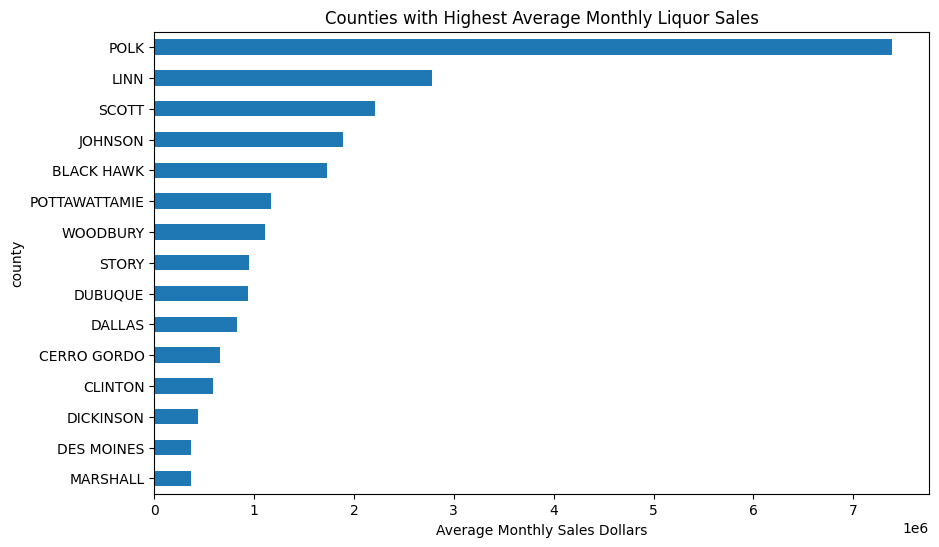

In [ ]:
county_avg.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Counties with Highest Average Monthly Liquor Sales"
)

plt.xlabel("Average Monthly Sales Dollars")
plt.show()

In [ ]:
booze["sales_dollars"].describe()

,sales_dollars
count,1.740700e+04
mean,3.259836e+05
std,9.337577e+05
min,7.941600e+02
25%,4.502111e+04
50%,9.428905e+04
75%,2.053419e+05
max,2.042934e+07


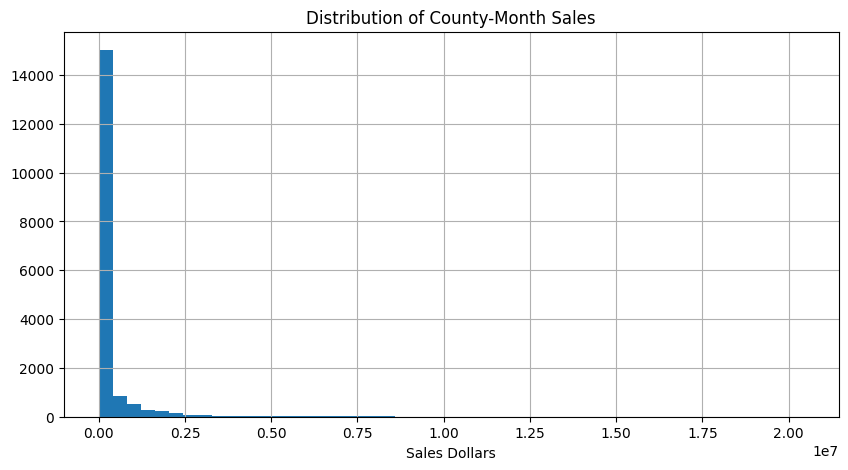

In [ ]:
booze["sales_dollars"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of County-Month Sales")
plt.xlabel("Sales Dollars")
plt.show()

In [ ]:
#New variables with county sales from: 1. Month before 2. Same month previous year 3. previous 3 month average 4. previous 12 month average

booze = booze.sort_values(
    ["county", "year_month"]
).reset_index(drop=True)

county_group = booze.groupby("county")

booze["sales_lag_1"] = (
    county_group["sales_dollars"]
    .shift(1)
)

booze["sales_lag_12"] = (
    county_group["sales_dollars"]
    .shift(12)
)

booze["sales_previous_3mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

booze["sales_previous_12mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(12).mean()
    )
)

In [ ]:
booze[
    [
        "sales_dollars",
        "sales_lag_1",
        "sales_lag_12",
        "sales_previous_3mo_avg",
        "sales_previous_12mo_avg"
    ]
].corr()

,sales_dollars,sales_lag_1,sales_lag_12,sales_previous_3mo_avg,sales_previous_12mo_avg
sales_dollars,1.000000,0.936233,0.944179,0.930185,0.945494
sales_lag_1,0.936233,1.000000,0.919001,0.971707,0.951014
sales_lag_12,0.944179,0.919001,1.000000,0.932853,0.954814
sales_previous_3mo_avg,0.930185,0.971707,0.932853,1.000000,0.976593
sales_previous_12mo_avg,0.945494,0.951014,0.954814,0.976593,1.000000


In [ ]:
#Create baseline prediction
booze_model = booze.dropna(
    subset=["sales_lag_12"]
).copy()

booze_model["baseline_prediction"] = (
    booze_model["sales_lag_12"]
)

In [ ]:
#Error metrics
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

In [ ]:
#3-fold split
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [ ]:
print(
    "Validation baseline RMSE:",
    rmse(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

print(
    "Validation baseline MAE:",
    mae(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

Validation baseline RMSE: 432509.76431835536
Validation baseline MAE: 98071.05350168348


In [ ]:
#Booze Model

from sklearn.linear_model import LinearRegression

X_train = train[
    ["sales_lag_12"]
]

y_train = train["sales_dollars"]

X_val = validation[
    ["sales_lag_12"]
]

y_val = validation["sales_dollars"]

model1 = LinearRegression()

model1.fit(
    X_train,
    y_train
)

pred1 = model1.predict(X_val)

print("RMSE:", rmse(y_val, pred1))
print("MAE:", mae(y_val, pred1))

print("Intercept:", model1.intercept_)
print("Coefficient:", model1.coef_)

RMSE: 431468.07849115494
MAE: 98823.36331521694
Intercept: 15397.123526570038
Coefficient: [0.99742224]


In [ ]:
#Better results may be caused due to multicollinearity

features2 = [
    "sales_lag_1",
    "sales_lag_12"
]

X_train = train[features2]
X_val = validation[features2]

model2 = LinearRegression()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_val)

print("RMSE:", rmse(y_val, pred2))
print("MAE:", mae(y_val, pred2))

RMSE: 346783.8483197493
MAE: 85920.14415395424


,0
sales_lag_1,0.382894
sales_lag_12,0.634414


In [ ]:
#Better results may be caused due to multicollinearity

features3 = [
    "sales_lag_1",
    "sales_lag_12",
    "sales_previous_3mo_avg",
    "sales_previous_12mo_avg"
]

model3 = LinearRegression()

model3.fit(
    train[features3],
    y_train
)

pred3 = model3.predict(
    validation[features3]
)

print("RMSE:", rmse(y_val, pred3))
print("MAE:", mae(y_val, pred3))

RMSE: 362666.81240227475
MAE: 87684.2101985545


In [ ]:
#New model for seasonality

month_dummies = pd.get_dummies(
    booze_model["month"],
    prefix="month",
    drop_first=True,
    dtype=int
)

booze_model = pd.concat(
    [booze_model, month_dummies],
    axis=1
)

In [ ]:
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [ ]:
month_features = [
    f"month_{i}"
    for i in range(2, 13)
]

features4 = [
    "sales_lag_1",
    "sales_lag_12",
] + month_features

model4 = LinearRegression()

model4.fit(
    train[features4],
    train["sales_dollars"]
)

pred4 = model4.predict(
    validation[features4]
)

print(
    "RMSE:",
    rmse(
        validation["sales_dollars"],
        pred4
    )
)

print(
    "MAE:",
    mae(
        validation["sales_dollars"],
        pred4
    )
)

RMSE: 342160.46153091633
MAE: 89310.45736086498


In [ ]:
results_booze = pd.DataFrame({
    "Model": [
        "Previous-year baseline",
        "Lag 12 regression",
        "Lag 1 + Lag 12",
        "Rolling history",
        "Lag 1 + Lag 12 + Month"
    ],

    "RMSE": [
        rmse(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        rmse(validation["sales_dollars"], pred1),
        rmse(validation["sales_dollars"], pred2),
        rmse(validation["sales_dollars"], pred3),
        rmse(validation["sales_dollars"], pred4)
    ],

    "MAE": [
        mae(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        mae(validation["sales_dollars"], pred1),
        mae(validation["sales_dollars"], pred2),
        mae(validation["sales_dollars"], pred3),
        mae(validation["sales_dollars"], pred4)
    ]
})

results_booze.sort_values("RMSE")

,Model,RMSE,MAE
4,Lag 1 + Lag 12 + Month,342160.461531,89310.457361
2,Lag 1 + Lag 12,346783.848320,85920.144154
3,Rolling history,362666.812402,87684.210199
1,Lag 12 regression,431468.078491,98823.363315
0,Previous-year baseline,432509.764318,98071.053502


END OF BOOZE, START OF DEAD

In [ ]:
#For dead, drop 2025 and 2026 data that has no population data, keep for booze
dead_monthly = df_main[
    df_main["county_population"].notna()
].copy()

In [ ]:
dead = (
    dead_monthly
    .groupby(
        ["county", "year"],
        as_index=False
    )
    .agg(
        sales_liters=(
            "sales_liters",
            "sum"
        ),

        sales_dollars=(
            "sales_dollars",
            "sum"
        ),

        sales_bottles=(
            "sales_bottles",
            "sum"
        ),

        county_population=(
            "county_population",
            "first"
        ),

        avg_alcohol_level_g210L=(
            "avg_alcohol_level_g210L",
            "first"
        ),

        num_tests=(
            "num_tests",
            "first"
        )
    )
)

In [ ]:
dead["liters_per_capita"] = (
    dead["sales_liters"]
    / dead["county_population"]
)

In [ ]:
dead.head()

,county,year,sales_liters,sales_dollars,sales_bottles,county_population,avg_alcohol_level_g210L,num_tests,liters_per_capita
0,ADAIR,2012,33297.02,413691.48,34894,7468.0,0.124,24.0,4.458626
1,ADAIR,2013,31159.97,378584.26,32112,7387.0,0.126,21.0,4.218217
2,ADAIR,2014,33383.60,413071.07,34466,7368.0,0.159,29.0,4.530890
3,ADAIR,2015,33957.85,424750.82,35049,7145.0,0.133,25.0,4.752673
4,ADAIR,2016,34773.16,444516.75,36071,7005.0,0.142,28.0,4.964049


In [ ]:
dead["liters_per_capita"].describe()

,liters_per_capita
count,1287.000000
mean,5.521088
std,3.047866
min,0.116174
25%,3.655524
50%,5.132168
75%,6.826776
max,31.400302


In [ ]:
dead.sort_values(
    "liters_per_capita",
    ascending=False
)[
    [
        "county",
        "year",
        "sales_liters",
        "county_population",
        "liters_per_capita"
    ]
].head(20)

,county,year,sales_liters,county_population,liters_per_capita
581,HOWARD,2021,99727.36,3176.0,31.400302
582,HOWARD,2022,94057.58,3163.0,29.736826
584,HOWARD,2024,75151.99,3105.0,24.203539
386,DICKINSON,2021,400141.76,17876.0,22.384301
387,DICKINSON,2022,401579.30,18052.0,22.245696
385,DICKINSON,2020,386052.82,17703.0,21.807198
583,HOWARD,2023,67020.40,3140.0,21.344076
389,DICKINSON,2024,382911.68,18158.0,21.087767
388,DICKINSON,2023,358413.79,18087.0,19.816099
384,DICKINSON,2019,317827.83,17258.0,18.416261


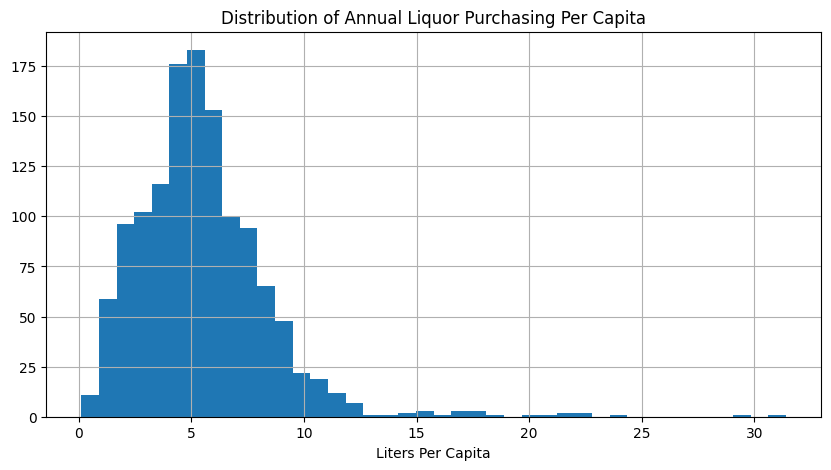

In [ ]:
dead["liters_per_capita"].hist(
    bins=40,
    figsize=(10, 5)
)

plt.xlabel("Liters Per Capita")
plt.title(
    "Distribution of Annual Liquor Purchasing Per Capita"
)

plt.show()

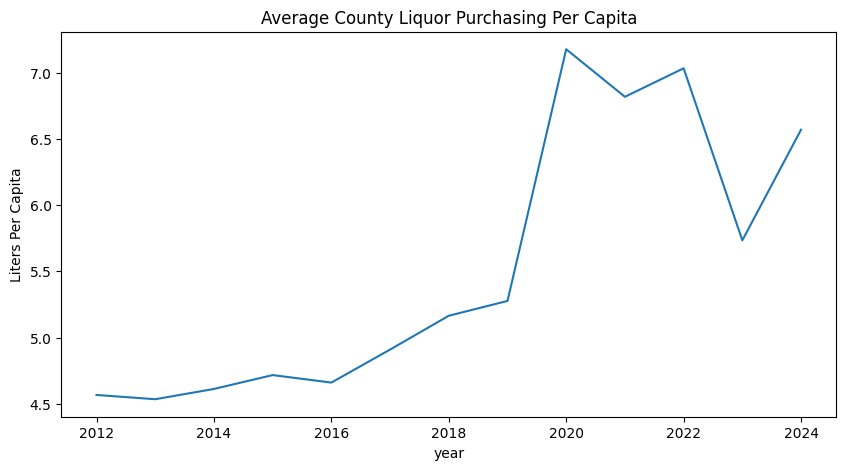

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

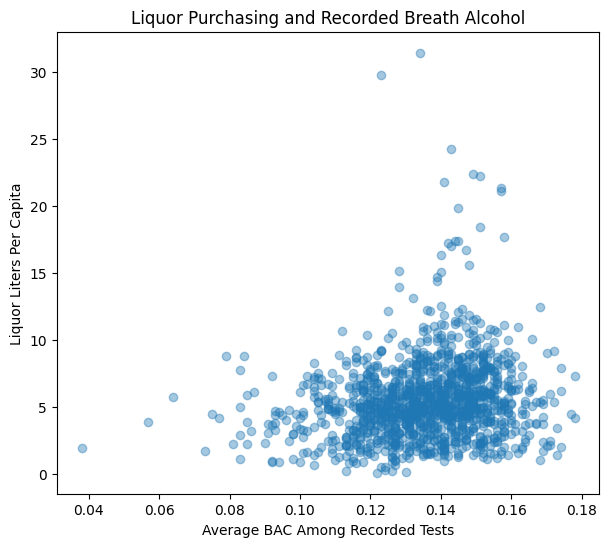

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dead["avg_alcohol_level_g210L"],
    dead["liters_per_capita"],
    alpha=0.4
)

plt.xlabel("Average BAC Among Recorded Tests")
plt.ylabel("Liquor Liters Per Capita")
plt.title("Liquor Purchasing and Recorded Breath Alcohol")

plt.show()

In [ ]:
dead[
    [
        "liters_per_capita",
        "avg_alcohol_level_g210L",
        "num_tests",
        "county_population"
    ]
].corr()

,liters_per_capita,avg_alcohol_level_g210L,num_tests,county_population
liters_per_capita,1.000000,0.176509,0.318397,0.314014
avg_alcohol_level_g210L,0.176509,1.000000,0.066375,0.120111
num_tests,0.318397,0.066375,1.000000,0.916127
county_population,0.314014,0.120111,0.916127,1.000000


In [ ]:
dead["tests_per_1000"] = (
    dead["num_tests"]
    / dead["county_population"]
    * 1000
)
dead["years_since_start"] = (
    dead["year"] - dead["year"].min()
)

In [ ]:
#Log population to account for large variance in populations

dead["log_population"] = np.log(
    dead["county_population"]
)

In [ ]:
dead_train = dead[
    dead["year"] <= 2022
].copy()

dead_val = dead[
    dead["year"].isin([2023, 2024])
].copy()

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    color="steelblue",
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

NameError: name 'dead' is not defined

In [ ]:
#Model 2: Time + BAC

dead_features2 = [
    "years_since_start",
    "avg_alcohol_level_g210L"
]

dead_model2 = LinearRegression()

dead_model2.fit(
    dead_train[dead_features2],
    dead_train["liters_per_capita"]
)

dead_pred2 = dead_model2.predict(
    dead_val[dead_features2]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred2
    )
)

pd.Series(
    dead_model2.coef_,
    index=dead_features2
)

RMSE: 3.4372222580542604


,0
years_since_start,0.275987
avg_alcohol_level_g210L,31.400162


In [ ]:
#Model 3: adding test frequency

dead_features3 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000"
]

dead_model3 = LinearRegression()

dead_model3.fit(
    dead_train[dead_features3],
    dead_train["liters_per_capita"]
)

dead_pred3 = dead_model3.predict(
    dead_val[dead_features3]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred3
    )
)

print(
    pd.Series(
        dead_model3.coef_,
        index=dead_features3
    )
)

RMSE: 3.353584162970485
years_since_start           0.374619
avg_alcohol_level_g210L    38.351779
tests_per_1000              0.512339
dtype: float64


In [ ]:
dead_features4 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000",
    "log_population"
]

dead_model4 = LinearRegression()

dead_model4.fit(
    dead_train[dead_features4],
    dead_train["liters_per_capita"]
)

dead_pred4 = dead_model4.predict(
    dead_val[dead_features4]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred4
    )
)

print(
    pd.Series(
        dead_model4.coef_,
        index=dead_features4
    )
)

RMSE: 3.187733398278088
years_since_start           0.371070
avg_alcohol_level_g210L    25.654618
tests_per_1000              0.476603
log_population              1.251081
dtype: float64


In [ ]:
results_dead = pd.DataFrame({
    "Model": [
        "Time trend",
        "Time + BAC",
        "Time + BAC + Tests",
        "Time + BAC + Tests + Population"
    ],

    "RMSE": [
        rmse(
            dead_val["liters_per_capita"],
            dead_pred1
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred2
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred3
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred4
        )
    ]
})

results_dead.sort_values("RMSE")

,Model,RMSE
3,Time + BAC + Tests + Population,3.187733
2,Time + BAC + Tests,3.353584
1,Time + BAC,3.437222
0,Time trend,3.445266
